# FailBench Dataset Inspection (whole-version aggregate)

Aggregate stats across an entire dataset version — every scene, every task. Use this to verify a full generation run before committing to ML training.

Companion to `visualize_dataset.ipynb` (which drills into a single task slice). Point `DATASET_ROOT` at `datasets/<version>/`.

In [1]:
import os, sys, glob, csv
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

DATASET_ROOT = "datasets/v10"   # edit this to inspect another version

scenes = sorted(
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
)
print(f"DATASET_ROOT = {DATASET_ROOT}")
print(f"scenes ({len(scenes)}): {scenes}")

DATASET_ROOT = datasets/v10
scenes (5): ['scene_cluttered', 'scene_grocery', 'scene_kitchen', 'scene_level2', 'scene_workshop']


## 1. Counts and disk usage

Per-(scene, task) sample counts and total bytes on disk. The first table tells you which tasks ran short of the planned trial budget — typically due to MuJoCo crashes during failure cascades.

In [2]:
rows = []
for scene in scenes:
    sdir = os.path.join(DATASET_ROOT, scene)
    tasks = sorted(t for t in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, t)))
    for task in tasks:
        tdir = os.path.join(sdir, task)
        files = glob.glob(os.path.join(tdir, "*.npz"))
        nbytes = sum(os.path.getsize(f) for f in files)
        rows.append((scene, task, len(files), nbytes))

scene_totals = defaultdict(lambda: [0, 0])
for s, t, n, b in rows:
    scene_totals[s][0] += n
    scene_totals[s][1] += b
grand_n = sum(v[0] for v in scene_totals.values())
grand_b = sum(v[1] for v in scene_totals.values())

print(f"{'scene':18s} {'task':22s} {'npz':>6s} {'MB':>9s}")
print("-" * 58)
for s, t, n, b in rows:
    print(f"{s:18s} {t:22s} {n:6d} {b/1024/1024:9.1f}")
print("-" * 58)
for s, (n, b) in scene_totals.items():
    print(f"{s:18s} {'(total)':22s} {n:6d} {b/1024/1024:9.1f}")
print("-" * 58)
print(f"{'GRAND TOTAL':40s} {grand_n:6d} {grand_b/1024/1024:9.1f}  ({grand_b/1024/1024/1024:.2f} GB)")

scene              task                      npz        MB
----------------------------------------------------------
scene_cluttered    clean_far                 275     742.3
scene_cluttered    clean_nominal             450    1236.1
scene_cluttered    clean_over                350     935.2
scene_cluttered    handover_far              200     546.6
scene_cluttered    handover_nominal          449    1212.0
scene_cluttered    handover_over             425    1164.7
scene_cluttered    stack_far                 450    1249.9
scene_cluttered    stack_nominal             449    1246.0
scene_cluttered    stack_over                375    1020.1
scene_grocery      clean_far                  50     137.6
scene_grocery      clean_nominal             500    1339.8
scene_grocery      clean_over                325     870.4
scene_grocery      handover_far              475    1285.9
scene_grocery      handover_nominal          450    1223.2
scene_grocery      handover_over             300     797

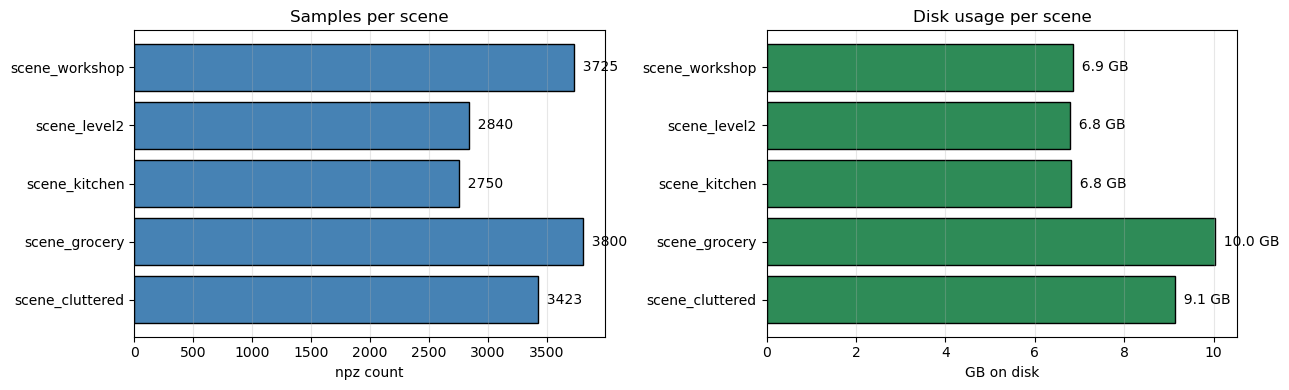

In [3]:
# Per-scene bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = list(scene_totals.keys())
ns = [scene_totals[s][0] for s in names]
bs = [scene_totals[s][1] / 1024**3 for s in names]
axes[0].barh(names, ns, color='steelblue', edgecolor='k')
axes[0].set(xlabel='npz count', title='Samples per scene')
axes[0].grid(axis='x', alpha=0.3)
for i, n in enumerate(ns):
    axes[0].text(n, i, f'  {n}', va='center')

axes[1].barh(names, bs, color='seagreen', edgecolor='k')
axes[1].set(xlabel='GB on disk', title='Disk usage per scene')
axes[1].grid(axis='x', alpha=0.3)
for i, b in enumerate(bs):
    axes[1].text(b, i, f'  {b:.1f} GB', va='center')
plt.tight_layout(); plt.show()

## 2. Manifest aggregation (cheap — reads CSVs, not npz)

Pulls scalar metadata from each task's `manifest.csv` so we don't have to open all 16,500+ npz files. Gives us trajectory_progress, contact counts, collision flags, qvel norm — enough for the diagnostics below.

In [4]:
manifests = []
for scene in scenes:
    for csv_path in sorted(glob.glob(os.path.join(DATASET_ROOT, scene, "*", "manifest.csv"))):
        task = os.path.basename(os.path.dirname(csv_path))
        with open(csv_path) as f:
            for r in csv.DictReader(f):
                r['scene'] = scene
                r['_task'] = task
                manifests.append(r)
print(f"loaded {len(manifests)} manifest rows")

# Convert numeric fields
for r in manifests:
    r['traj_progress'] = float(r['traj_progress'])
    r['num_contacts'] = int(r['num_contacts'])
    r['num_failure_modes'] = int(r['num_failure_modes'])
    r['pre_qvel_norm'] = float(r['pre_qvel_norm'])
    r['traj_id'] = int(r['traj_id'])
    r['had_any_collision'] = (r['had_any_collision'].lower() == 'true')
    r['n_impacted_geoms'] = (
        len(r['impacted_geom_ids'].split(';')) if r['impacted_geom_ids'] else 0
    )
print(f"sample row keys: {list(manifests[0].keys())}")

loaded 16532 manifest rows
sample row keys: ['experiment_id', 'task_id', 'traj_id', 'trajectory_file', 'seed', 'traj_progress', 'num_contacts', 'num_failure_modes', 'had_any_collision', 'impacted_geom_ids', 'pre_qvel_norm', 'npz_file', 'scene', '_task', 'n_impacted_geoms']


## 3. traj_progress coverage per scene

Stratification check. Each trajectory had K=5 draws per segment × 5 segments = 25 trials. The histogram should show roughly even mass across [0, 1] (segments are not strictly equal width in fraction-space, so expect minor bumpiness).

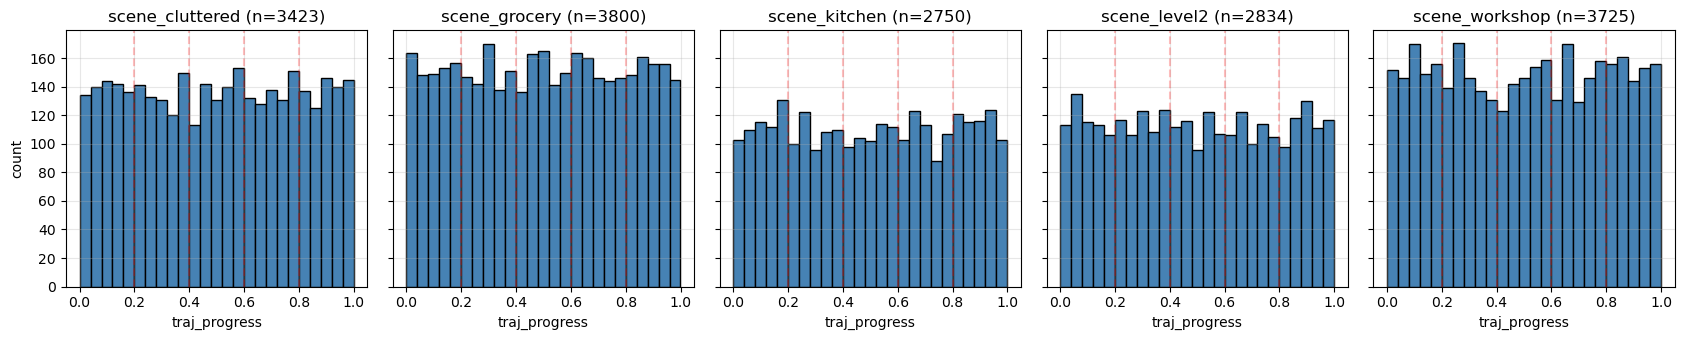

In [5]:
fig, axes = plt.subplots(1, len(scenes), figsize=(3.4 * len(scenes), 3.5), sharey=True)
if len(scenes) == 1: axes = [axes]
for ax, scene in zip(axes, scenes):
    progs = [r['traj_progress'] for r in manifests if r['scene'] == scene]
    ax.hist(progs, bins=25, color='steelblue', edgecolor='k')
    ax.set(title=f'{scene} (n={len(progs)})', xlabel='traj_progress')
    for x in [0.2, 0.4, 0.6, 0.8]:
        ax.axvline(x, color='r', ls='--', alpha=0.25)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('count')
plt.tight_layout(); plt.show()

## 4. Pre-failure arm speed (`pre_qvel_norm`)

How fast the arm was moving when the failure was injected. Higher speed → more energetic post-failure cascade. Bimodality is expected: the arm decelerates near segment endpoints (descend → grasp settle, place → release) and accelerates mid-segment.

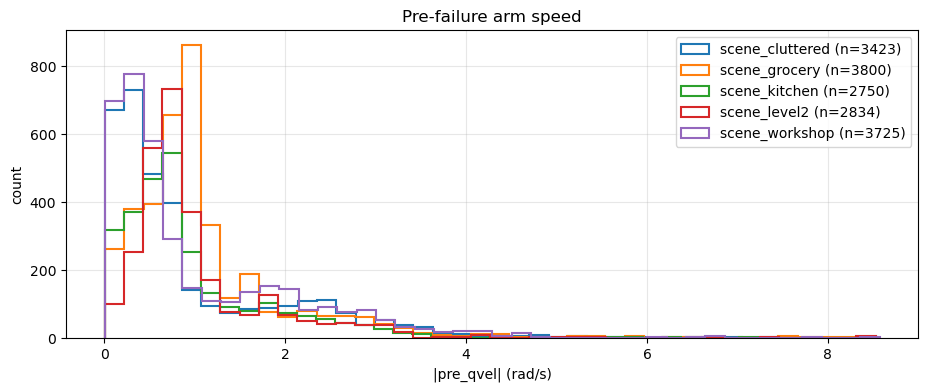

all-scenes: median=0.731, mean=1.071, max=8.573


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for scene in scenes:
    qv = [r['pre_qvel_norm'] for r in manifests if r['scene'] == scene]
    ax.hist(qv, bins=40, histtype='step', label=f'{scene} (n={len(qv)})', linewidth=1.5)
ax.set(xlabel='|pre_qvel| (rad/s)', ylabel='count', title='Pre-failure arm speed')
ax.grid(alpha=0.3); ax.legend(); plt.show()

all_qv = [r['pre_qvel_norm'] for r in manifests]
print(f'all-scenes: median={np.median(all_qv):.3f}, mean={np.mean(all_qv):.3f}, max={np.max(all_qv):.3f}')

## 5. Contacts per sample (label density)

Each npz aggregates contacts across all 6 failure-mode forks. Higher contact counts = harder failures (ALL_JOINTS, MULTI_JOINT) or more cluttered scenes. Tail samples with very low contact counts are early-mission failures (failure happened before the arm entered the workspace).

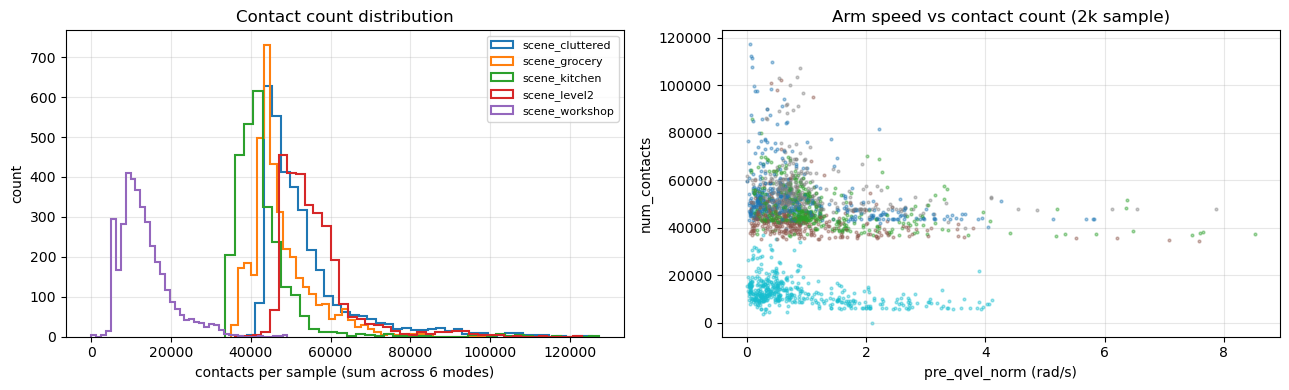

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scene in scenes:
    nc = [r['num_contacts'] for r in manifests if r['scene'] == scene]
    axes[0].hist(nc, bins=40, histtype='step', linewidth=1.5, label=scene)
axes[0].set(xlabel='contacts per sample (sum across 6 modes)',
            ylabel='count', title='Contact count distribution')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# Pre-qvel vs num_contacts scatter (sample 2k for speed)
rng = np.random.default_rng(0)
if len(manifests) > 2000:
    sub = [manifests[i] for i in rng.choice(len(manifests), 2000, replace=False)]
else:
    sub = manifests
scene2color = {s: c for s, c in zip(scenes, plt.cm.tab10(np.linspace(0, 1, len(scenes))))}
for r in sub:
    axes[1].scatter(r['pre_qvel_norm'], r['num_contacts'],
                    c=[scene2color[r['scene']]], s=4, alpha=0.4)
axes[1].set(xlabel='pre_qvel_norm (rad/s)', ylabel='num_contacts',
            title='Arm speed vs contact count (2k sample)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Collision rate and impacted-geom diversity

`had_any_collision` is True for nearly every sample (the arm always touches *something* during the 500-step settle), so it's not a useful learning target. The interesting per-sample signal is the `impacted_geom_ids` set — how many distinct geoms got hit, and the diversity of impact pairs across the dataset.

had_any_collision rate: 1.0000


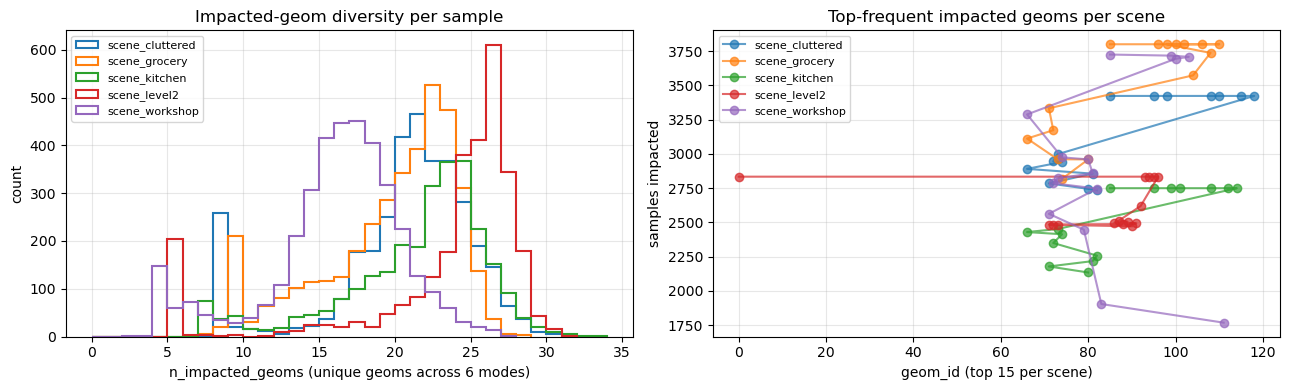

In [8]:
any_coll = sum(1 for r in manifests if r['had_any_collision']) / len(manifests)
print(f"had_any_collision rate: {any_coll:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scene in scenes:
    counts = [r['n_impacted_geoms'] for r in manifests if r['scene'] == scene]
    axes[0].hist(counts, bins=range(0, max(counts) + 2),
                 histtype='step', linewidth=1.5, label=scene)
axes[0].set(xlabel='n_impacted_geoms (unique geoms across 6 modes)',
            ylabel='count', title='Impacted-geom diversity per sample')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# Per-scene impacted-geom-ID frequency: what gets hit, scene-by-scene
for scene in scenes:
    cnt = Counter()
    for r in manifests:
        if r['scene'] != scene: continue
        for g in r['impacted_geom_ids'].split(';'):
            if g: cnt[int(g)] += 1
    top = cnt.most_common(15)
    if not top: continue
    axes[1].plot([g for g, _ in top], [c for _, c in top],
                 marker='o', label=scene, alpha=0.7)
axes[1].set(xlabel='geom_id (top 15 per scene)', ylabel='samples impacted',
            title='Top-frequent impacted geoms per scene')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Pre-failure config diversity (a sample of pre_qpos)

The whole dataset's value depends on having diverse pre-failure arm configurations. Loads `pre_qpos` from a random subset of npz (~1k samples) and shows per-joint coverage. If any joint is collapsed (e.g. all values within 0.01 rad), the dataset is biased and the planner won't learn meaningfully across that joint.

In [9]:
import zipfile
all_files = []
for scene in scenes:
    all_files.extend(glob.glob(os.path.join(DATASET_ROOT, scene, "*", "*.npz")))
rng = np.random.default_rng(42)
sample_n = min(1000, len(all_files))
sample_files = [all_files[i] for i in rng.choice(len(all_files), sample_n, replace=False)]
print(f"loading pre_qpos from {sample_n} npz...")
qposes_list, corrupted = [], []
for f in sample_files:
    try:
        qposes_list.append(np.load(f, allow_pickle=True)["pre_qpos"])
    except (zipfile.BadZipFile, OSError, KeyError, EOFError) as e:
        corrupted.append((f, type(e).__name__))
qposes = np.array(qposes_list)
print(f"loaded {len(qposes)} ok, {len(corrupted)} corrupted ({100*len(corrupted)/sample_n:.2f}%)")
if corrupted:
    print("examples (likely worker crashes mid-write — small file size = truncated):")
    for f, e in corrupted[:5]:
        sz = os.path.getsize(f)
        print(f"  {e:14s} size={sz:>8d}B  {f}")
print(f"qposes shape: {qposes.shape}")


loading pre_qpos from 1000 npz...


loaded 1000 ok, 0 corrupted (0.00%)
qposes shape: (1000, 7)


## 8. Yield audit

How close did each task come to its planned trial count? `n_pkls × 25` is the target (5 segments × 5 per_segment). Anything below ~95% is a candidate for re-running, but small shortfalls just reflect MuJoCo crashes during heavy contact cascades — accepted as part of the PoC dataset.

In [10]:
import pickle
audit_rows = []
for scene in scenes:
    sdir = os.path.join(DATASET_ROOT, scene)
    for task in sorted(os.listdir(sdir)):
        tdir = os.path.join(sdir, task)
        if not os.path.isdir(tdir): continue
        actual = len(glob.glob(os.path.join(tdir, '*.npz')))
        # planned = n_pkls * 25
        pkls = sorted(glob.glob(f'scenes/{scene}/trajs/{scene}_{task}_*.pkl'))
        planned = len(pkls) * 25
        yield_pct = (actual / planned * 100) if planned else float('nan')
        audit_rows.append((scene, task, planned, actual, yield_pct))

audit_rows.sort(key=lambda x: x[4])  # worst yield first

print(f"{'scene':18s} {'task':22s} {'planned':>8s} {'actual':>7s} {'yield%':>8s}")
print("-" * 67)
for s, t, p, a, y in audit_rows:
    flag = ' !' if y < 95 else ''
    print(f"{s:18s} {t:22s} {p:8d} {a:7d} {y:7.1f}%{flag}")

all_planned = sum(p for _, _, p, _, _ in audit_rows)
all_actual = sum(a for _, _, _, a, _ in audit_rows)
print("-" * 67)
print(f"{'GRAND TOTAL':40s} {all_planned:8d} {all_actual:7d} {100*all_actual/all_planned:7.2f}%")

scene              task                    planned  actual   yield%
-------------------------------------------------------------------
scene_level2       handover_nominal            250     224    89.6% !
scene_level2       clean_over                  250     226    90.4% !
scene_level2       sort_over                   250     229    91.6% !
scene_level2       handover_over               250     238    95.2%
scene_level2       sort_far                    250     238    95.2%
scene_level2       sort_nominal                250     238    95.2%
scene_level2       stack_over                  250     238    95.2%
scene_level2       clean_far                   250     240    96.0%
scene_level2       clean_nominal               250     241    96.4%
scene_level2       stack_far                   250     241    96.4%
scene_level2       handover_far                250     243    97.2%
scene_level2       stack_nominal               250     244    97.6%
scene_cluttered    handover_nominal       

## 9. Visual sample tour (5 representative samples)

Five samples drawn evenly across `traj_progress` so we see the failure injected at different mission phases (approach → place). For each: front-cam RGB at the failure instant, wrist-cam RGB, post-failure front-cam, depth maps, and the contact distribution colored by failure mode.

In [11]:
import zipfile
import matplotlib.cm as cm

rows_with_path = []
for r in manifests:
    p = os.path.join(DATASET_ROOT, r['scene'], r['_task'], r['npz_file'])
    rows_with_path.append((r['traj_progress'], p, r['scene'], r['_task'], r))
rows_with_path.sort(key=lambda x: x[0])

n_total = len(rows_with_path)
picks_idx = [int(n_total * (k + 0.5) / 5) for k in range(5)]
picks = [rows_with_path[i] for i in picks_idx]

loaded = []
for prog, path, scene, task, r in picks:
    try:
        d = dict(np.load(path, allow_pickle=True))
        loaded.append((prog, path, scene, task, r, d))
    except (zipfile.BadZipFile, OSError, KeyError, EOFError) as e:
        print(f'skipping corrupted {path}: {type(e).__name__}')
print(f'showing {len(loaded)} samples:')
for prog, path, scene, task, r, _ in loaded:
    print(f'  prog={prog:.2f}  {scene}/{task}  traj_id={r["traj_id"]}  '
          f'qvel={r["pre_qvel_norm"]:.2f}  contacts={r["num_contacts"]}')

showing 5 samples:
  prog=0.10  scene_level2/sort_over  traj_id=8  qvel=3.15  contacts=47711
  prog=0.29  scene_kitchen/sort_over  traj_id=3  qvel=0.16  contacts=41772
  prog=0.50  scene_cluttered/stack_nominal  traj_id=9  qvel=0.71  contacts=48353
  prog=0.70  scene_cluttered/handover_over  traj_id=11  qvel=1.31  contacts=50214
  prog=0.90  scene_cluttered/handover_nominal  traj_id=17  qvel=0.38  contacts=47602


### 9a. Cameras (pre / wrist / post)

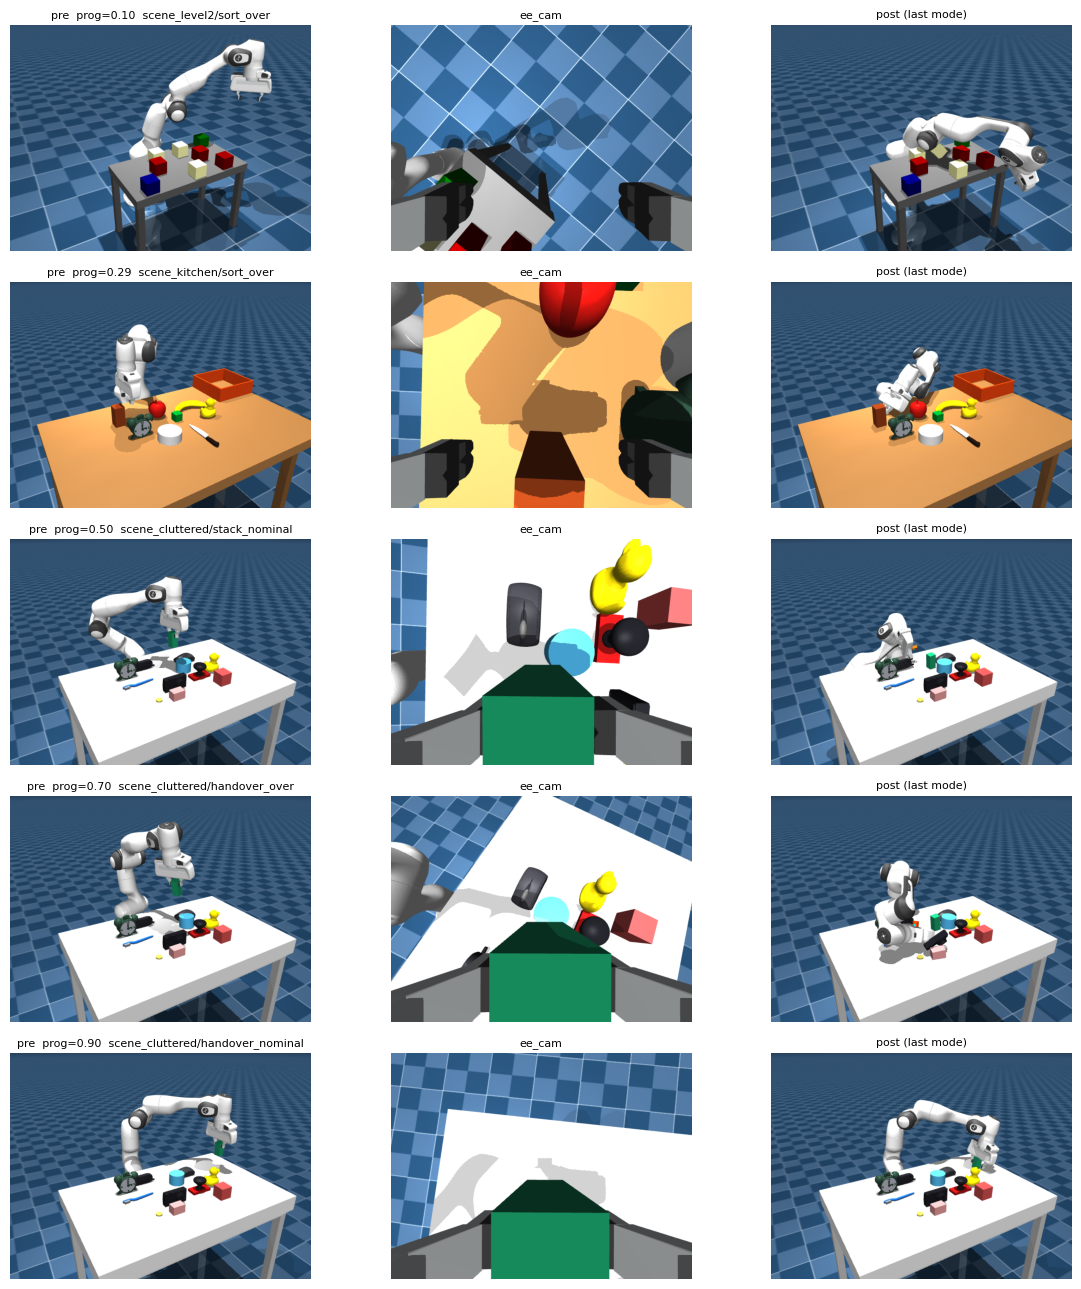

In [12]:
fig, axes = plt.subplots(len(loaded), 3, figsize=(12, 2.6 * len(loaded)))
if len(loaded) == 1: axes = axes[None, :]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    axes[i, 0].imshow(d['pre_rgb'])
    axes[i, 0].set_title(f'pre  prog={prog:.2f}  {scene}/{task}', fontsize=8)
    axes[i, 1].imshow(d['ee_cam_rgb'])
    axes[i, 1].set_title('ee_cam', fontsize=8)
    axes[i, 2].imshow(d['post_rgb'])
    axes[i, 2].set_title('post (last mode)', fontsize=8)
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

### 9b. Depth maps (front and wrist, clipped 0.05–2.0 m)

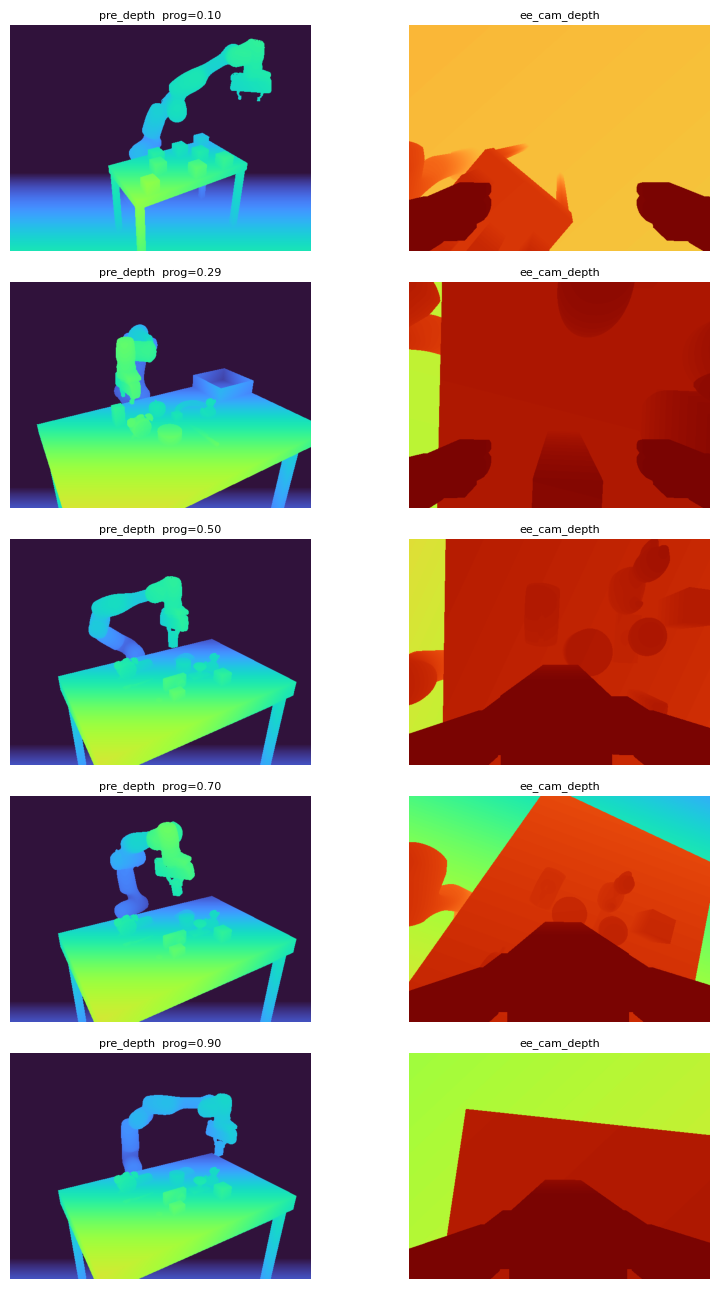

In [13]:
near, far = 0.05, 2.0
fig, axes = plt.subplots(len(loaded), 2, figsize=(9, 2.6 * len(loaded)))
if len(loaded) == 1: axes = axes[None, :]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    pd_img = np.clip(d['pre_depth'], near, far)
    ed_img = np.clip(d['ee_cam_depth'], near, far)
    axes[i, 0].imshow(pd_img, cmap='turbo_r', vmin=near, vmax=far)
    axes[i, 0].set_title(f'pre_depth  prog={prog:.2f}', fontsize=8)
    axes[i, 1].imshow(ed_img, cmap='turbo_r', vmin=near, vmax=far)
    axes[i, 1].set_title('ee_cam_depth', fontsize=8)
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

### 9c. Contact distribution (top-down X–Y, colored by failure mode)

Marker size scales with contact-force magnitude. ALL_JOINTS scatters contacts widely (whole-arm collapse); GRIPPER_OPEN concentrates them near the dropped object.

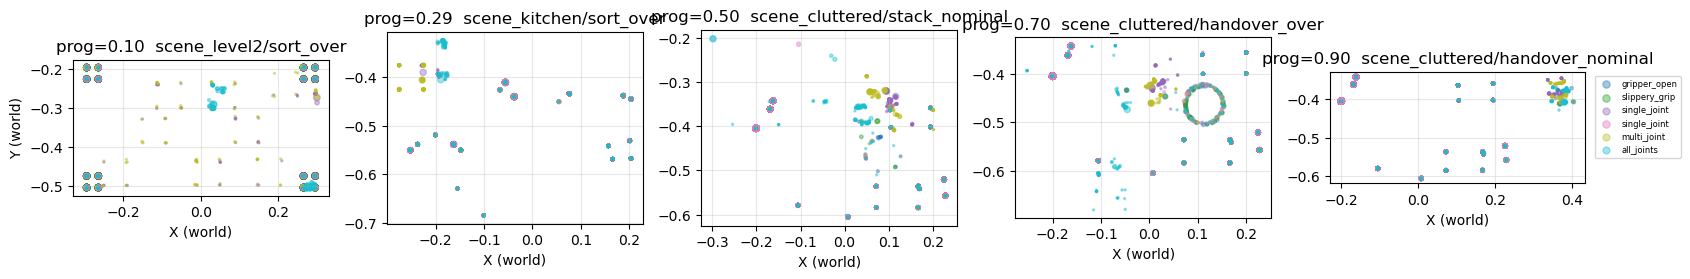

In [14]:
fig, axes = plt.subplots(1, len(loaded), figsize=(3.4 * len(loaded), 3.6))
if len(loaded) == 1: axes = [axes]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    ax = axes[i]
    pos = d['contact_positions']; forces = d['contact_forces']; fids = d['contact_failure_id']
    modes = list(d['failure_modes'])
    colors = cm.tab10(np.linspace(0, 1, len(modes)))
    for mid, (mode, c) in enumerate(zip(modes, colors)):
        mask = fids == mid
        if not mask.any(): continue
        p = pos[mask]
        mag = np.linalg.norm(forces[mask, :3], axis=1)
        if len(p) > 400:
            sel = np.random.default_rng(0).choice(len(p), 400, replace=False)
            p, mag = p[sel], mag[sel]
        sizes = 2 + 18 * (mag / (mag.max() + 1e-6))
        ax.scatter(p[:, 0], p[:, 1], s=sizes, c=[c], alpha=0.4, label=mode)
    ax.set(title=f'prog={prog:.2f}  {scene}/{task}',
           xlabel='X (world)', ylabel='Y (world)' if i == 0 else '')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == len(loaded) - 1:
        ax.legend(fontsize=6, markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

### 9d. Ground-truth contacts overlaid on `pre_rgb`

For each of the 5 samples, project the world-frame `contact_positions` into the front-cam pinhole using `ContactProjector`, draw them on top of `pre_rgb`, color by failure mode, scale by `|force|`. This is the closest visual to the supervised target an image-conditioned contact model would predict: given the front-cam pre-failure observation, where in the image are the post-failure contacts?

Caveat — the *pre*-failure image and *post*-failure contacts are from different time instants, so contacts can fall on objects that have moved. The overlay is a faithful visual of the labels we ship in the npz, not a registration claim.

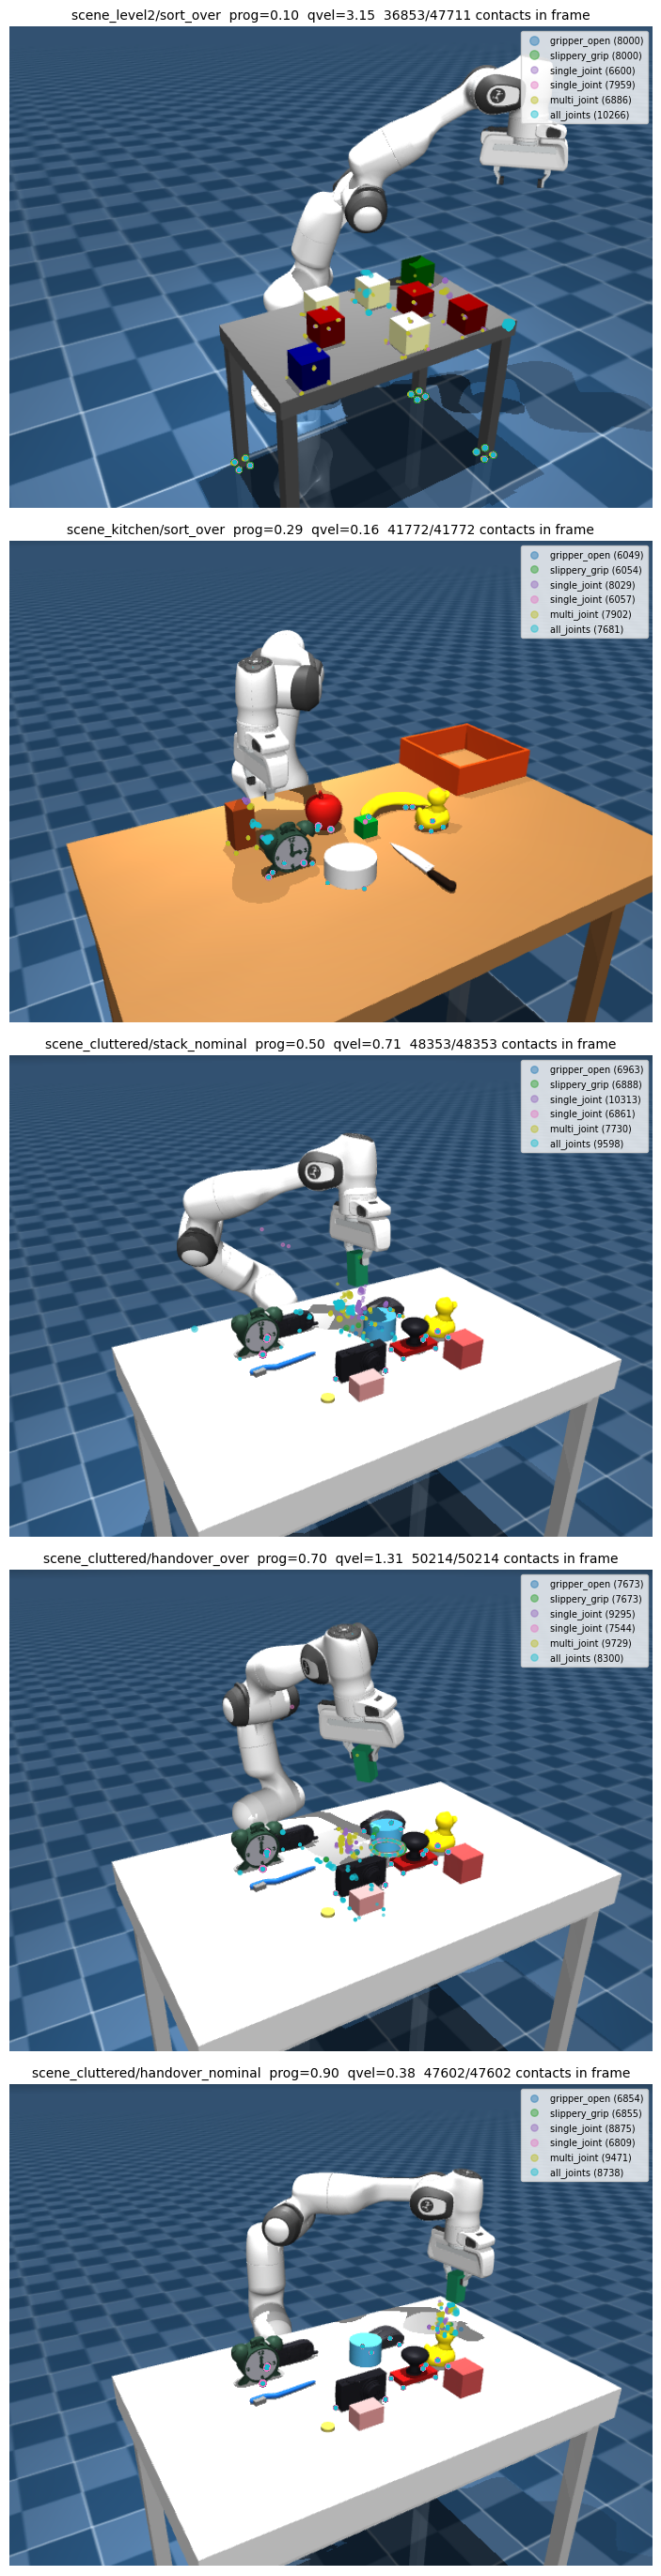

In [15]:
import mujoco
from planner.experiments.data_capture import ContactProjector

# Cache one model + projector per scene so we don't reload for each sample.
_proj_cache = {}
def _projector_for(scene):
    if scene not in _proj_cache:
        m = mujoco.MjModel.from_xml_path(f'scenes/{scene}/scene.xml')
        _proj_cache[scene] = ContactProjector(m, width=640, height=480, camera_name='front_cam')
    return _proj_cache[scene]

fig, axes = plt.subplots(len(loaded), 1, figsize=(8, 5.5 * len(loaded)))
if len(loaded) == 1: axes = [axes]
H, W = 480, 640
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    ax = axes[i]
    proj = _projector_for(scene)
    pos    = d['contact_positions']
    forces = d['contact_forces']
    fids   = d['contact_failure_id']
    modes  = list(d['failure_modes'])
    pixels, depths = proj.project(pos)
    visible = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < W) \
                            & (pixels[:, 1] >= 0) & (pixels[:, 1] < H)
    ax.imshow(d['pre_rgb'])
    colors = cm.tab10(np.linspace(0, 1, len(modes)))
    for mid, (mode, c) in enumerate(zip(modes, colors)):
        mask = (fids == mid) & visible
        if not mask.any(): continue
        p = pixels[mask]
        mag = np.linalg.norm(forces[mask, :3], axis=1)
        if len(p) > 600:
            sel = np.random.default_rng(0).choice(len(p), 600, replace=False)
            p, mag = p[sel], mag[sel]
        sizes = 3 + 18 * (mag / (mag.max() + 1e-6))
        ax.scatter(p[:, 0], p[:, 1], s=sizes, c=[c], alpha=0.45,
                   label=f'{mode} ({int((fids == mid).sum())})')
    n_visible = int(visible.sum())
    ax.set_title(f'{scene}/{task}  prog={prog:.2f}  '
                 f'qvel={r["pre_qvel_norm"]:.2f}  '
                 f'{n_visible}/{len(pos)} contacts in frame', fontsize=10)
    ax.legend(fontsize=7, markerscale=1.5, loc='upper right')
    ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.axis('off')
plt.tight_layout(); plt.show()

## 10. Summary for downstream ML

If everything above looks healthy, the dataset at `DATASET_ROOT` is ready for training. Reminders:

- **Each npz = 6 training examples** (one per failure mode tag in `contact_failure_id`).
- **Trajectory-level split** to avoid leakage: trials sharing `(scene, task_id, traj_id)` should not straddle train/test.
- **Drop ubiquitous geoms** (floor=0, fingertips ~93–96) from the multi-label target — they're contact-by-construction and dominate the loss.
- **PoC OOD recipe**: hold out one scene (recommended `scene_grocery` for its unique shelf/wall geometry); split the other four 80/10/10 at the trajectory level.
- **Failure-mode probabilities** are stored in `failure_probs` per npz — apply at training/eval time as importance weights, no re-generation needed.